In [23]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import *

## 1. Загрузка данных

In [24]:
df_players = load_data('../data/raw/players_fifa21.csv')
df_players.head(3)

Загружено: 19,020 строк × 90 столбцов


,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,158023,L. Messi,Lionel Messi,33,170,72,https://cdn.sofifa.com/players/158/023/21_60.png,Argentina,93,93,...,93,90,93,69,68,69,65,55,65,22
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,35,187,83,https://cdn.sofifa.com/players/020/801/21_60.png,Portugal,92,92,...,91,84,91,68,64,68,64,57,64,23
2,188545,R. Lewandowski,Robert Lewandowski,31,185,81,https://cdn.sofifa.com/players/188/545/21_60.png,Poland,92,92,...,87,83,87,67,69,67,64,63,64,22


In [25]:
df_teams = load_data('../data/raw/teams_fifa21.csv')
df_teams.head(3)

Загружено: 731 строк × 14 столбцов


,ID,Name,League,LeagueId,Overall,Attack,Midfield,Defence,TransferBudget,DomesticPrestige,IntPrestige,Players,StartingAverageAge,AllTeamAverageAge
0,1,Arsenal,English Premier League (1),13,80,83,79,79,80000000,7,7,33,24.7,23.6
1,2,Aston Villa,English Premier League (1),13,77,77,77,77,37500000,2,2,29,24.2,24.0
2,1808,Brighton & Hove Albion,English Premier League (1),13,75,75,76,76,36000000,2,1,33,25.6,23.6


## 2. Merge игроков и команд

In [26]:
df = merge_data(df_players, df_teams)
df.head(3)

После merge: 19,020 строк × 104 столбцов


,P_ID,P_Name,P_FullName,P_Age,P_Height,P_Weight,P_PhotoUrl,P_Nationality,P_Overall,P_Potential,...,C_Overall,C_Attack,C_Midfield,C_Defence,C_TransferBudget,C_DomesticPrestige,C_IntPrestige,C_Players,C_StartingAverageAge,C_AllTeamAverageAge
0,158023,L. Messi,Lionel Messi,33,170,72,https://cdn.sofifa.com/players/158/023/21_60.png,Argentina,93,93,...,84.0,87.0,82.0,82.0,130000000.0,10.0,9.0,32.0,27.4,24.8
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,35,187,83,https://cdn.sofifa.com/players/020/801/21_60.png,Portugal,92,92,...,83.0,87.0,81.0,83.0,105000000.0,10.0,10.0,26.0,27.8,26.0
2,188545,R. Lewandowski,Robert Lewandowski,31,185,81,https://cdn.sofifa.com/players/188/545/21_60.png,Poland,92,92,...,84.0,92.0,85.0,82.0,100000000.0,10.0,10.0,23.0,26.2,25.3


## 3. Пропуски и дубликаты

In [27]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
print(f'Столбцов с пропусками: {len(missing_df)}')
print(missing_df.to_string())

Столбцов с пропусками: 19
                      count    pct
P_NationalPosition    17862  93.91
P_NationalNumber      17862  93.91
P_ClubPosition          245   1.29
P_ClubNumber            245   1.29
P_ContractUntil         245   1.29
C_ID                    245   1.29
C_Name                  245   1.29
C_League                245   1.29
C_LeagueId              245   1.29
C_Overall               245   1.29
C_Attack                245   1.29
C_Midfield              245   1.29
C_Defence               245   1.29
C_TransferBudget        245   1.29
C_DomesticPrestige      245   1.29
C_IntPrestige           245   1.29
C_Players               245   1.29
C_StartingAverageAge    245   1.29
C_AllTeamAverageAge     245   1.29


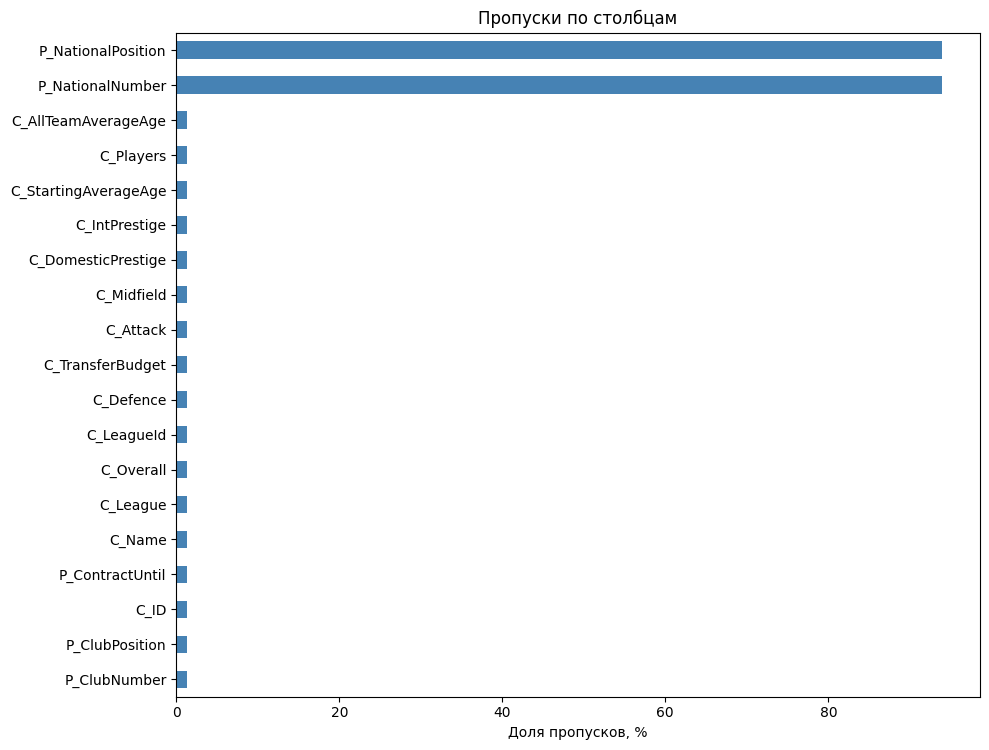

In [28]:
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Доля пропусков, %')
    ax.set_title('Пропуски по столбцам')
    plt.tight_layout()
    plt.show()

In [29]:
dups = df.duplicated(subset=['P_FullName']).sum()
print(f'Дубликатов по P_FullName: {dups} ({dups/len(df)*100:.2f}%)')
if dups > 0:
    display(df[df.duplicated(subset=['P_FullName'], keep=False)]
            .sort_values('P_FullName')[['P_FullName', 'P_Club', 'P_Overall', TARGET]].head(10))

Дубликатов по P_FullName: 212 (1.11%)


,P_FullName,P_Club,P_Overall,P_WageEUR
12649,Aaron Martin,Hamilton Academical FC,63,2000
13043,Aaron Martin,Harrogate Town,63,3000
2076,Adam Hložek,Sparta Praha,74,500
14445,Adam Hložek,Sparta Praha,74,500
13372,Adama Fofana,Varbergs BoIS,62,500
18429,Adama Fofana,Vejle Boldklub,53,1000
6582,Adama Traoré,Melbourne Victory,68,4000
3209,Adama Traoré,Hatayspor,72,11000
810,Adama Traoré Diarra,Wolverhampton Wanderers,78,72000
14427,Adama Traoré Diarra,Wolverhampton Wanderers,78,72000


## 4. Распределение таргета (до очистки)

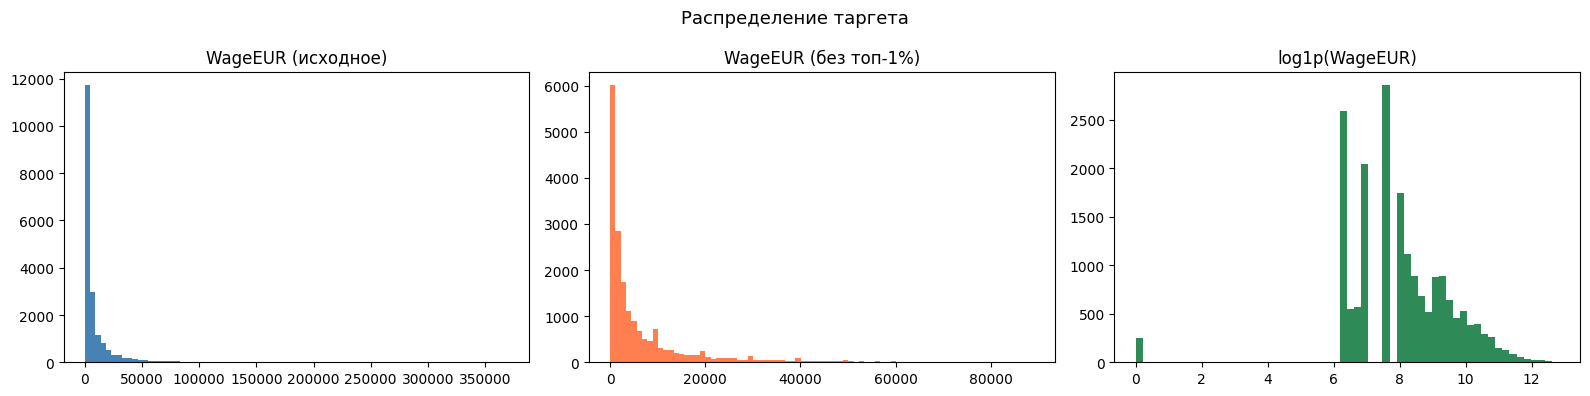

count     19020.000000
mean       9108.866982
std       19570.311736
min           0.000000
25%        1000.000000
50%        3000.000000
75%        9000.000000
max      370000.000000

Skewness: 6.52 → после log1p: -1.12


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df[TARGET].dropna(), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('WageEUR (исходное)')

clip99 = df[TARGET].quantile(0.99)
axes[1].hist(df[df[TARGET] < clip99][TARGET], bins=80, color='coral', edgecolor='none')
axes[1].set_title('WageEUR (без топ-1%)')

axes[2].hist(np.log1p(df[TARGET].dropna()), bins=60, color='seagreen', edgecolor='none')
axes[2].set_title('log1p(WageEUR)')

plt.suptitle('Распределение таргета', fontsize=13)
plt.tight_layout()
plt.show()

print(df[TARGET].describe().to_string())
print(f'\nSkewness: {df[TARGET].skew():.2f} → после log1p: {np.log1p(df[TARGET]).skew():.2f}')

## 5. Очистка данных

In [31]:
df_clean = clean_data(df)
df_clean.head(3)

После очистки: 18,775 строк × 104 столбцов


,P_ID,P_Name,P_FullName,P_Age,P_Height,P_Weight,P_PhotoUrl,P_Nationality,P_Overall,P_Potential,...,C_Overall,C_Attack,C_Midfield,C_Defence,C_TransferBudget,C_DomesticPrestige,C_IntPrestige,C_Players,C_StartingAverageAge,C_AllTeamAverageAge
0,158023,L. Messi,Lionel Messi,33,170,72,https://cdn.sofifa.com/players/158/023/21_60.png,Argentina,93,93,...,84.0,87.0,82.0,82.0,130000000.0,10.0,9.0,32.0,27.4,24.8
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,35,187,83,https://cdn.sofifa.com/players/020/801/21_60.png,Portugal,92,92,...,83.0,87.0,81.0,83.0,105000000.0,10.0,10.0,26.0,27.8,26.0
2,188545,R. Lewandowski,Robert Lewandowski,31,185,81,https://cdn.sofifa.com/players/188/545/21_60.png,Poland,92,92,...,84.0,92.0,85.0,82.0,100000000.0,10.0,10.0,23.0,26.2,25.3


## 6. Выбросы в числовых признаках

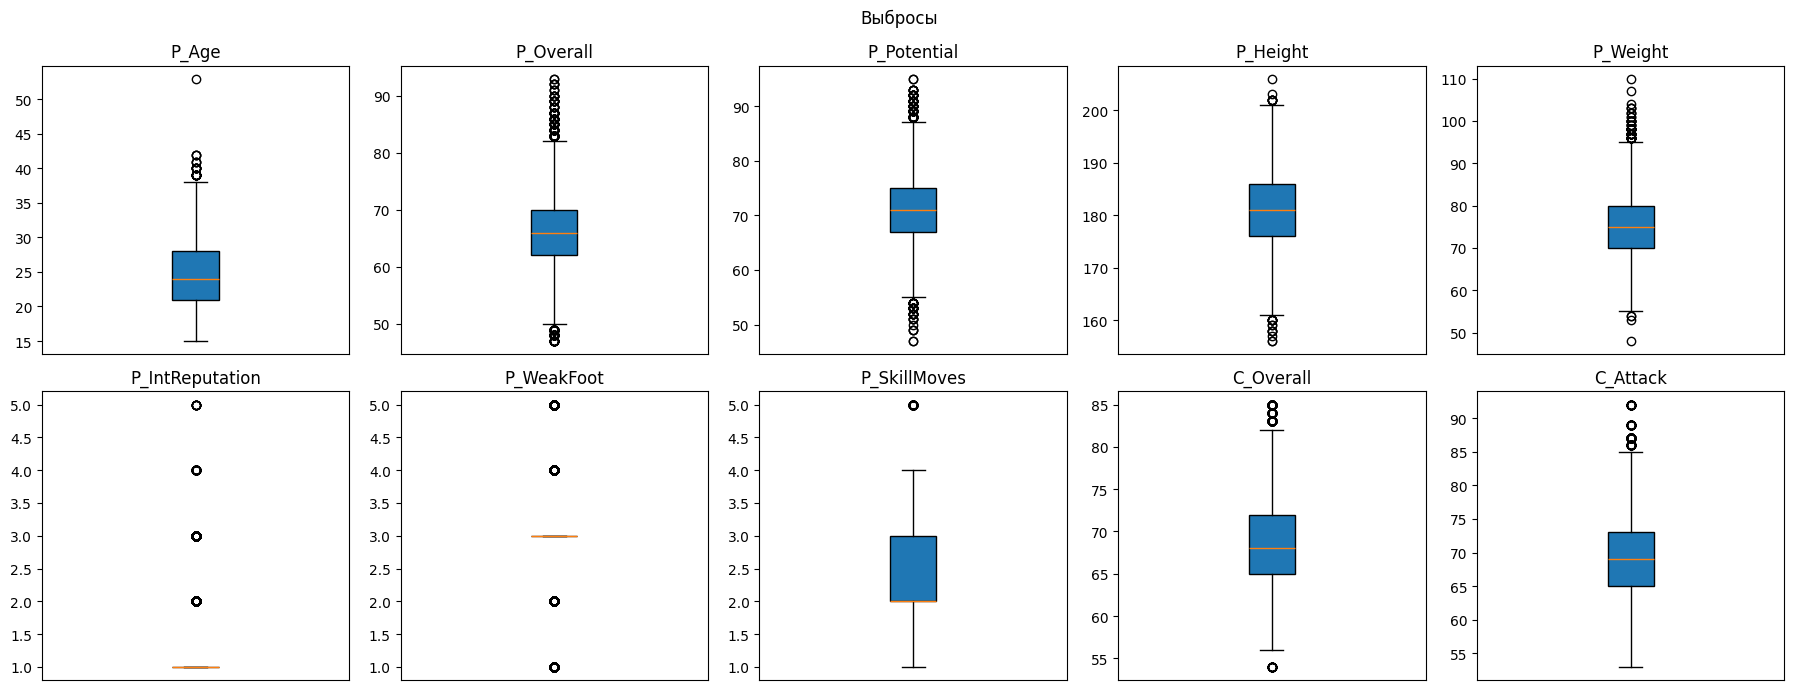

In [32]:
num_cols_for_boxplot = [
    'P_Age', 'P_Overall', 'P_Potential',
    'P_Height', 'P_Weight',
    'P_IntReputation', 'P_WeakFoot', 'P_SkillMoves',
    'C_Overall', 'C_Attack'
]
num_cols_for_boxplot = [c for c in num_cols_for_boxplot if c in df_clean.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols_for_boxplot):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True)
    axes[i].set_title(col)
    axes[i].set_xticks([])
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Выбросы')
plt.tight_layout()
plt.show()

## 7. Корреляция с таргетом

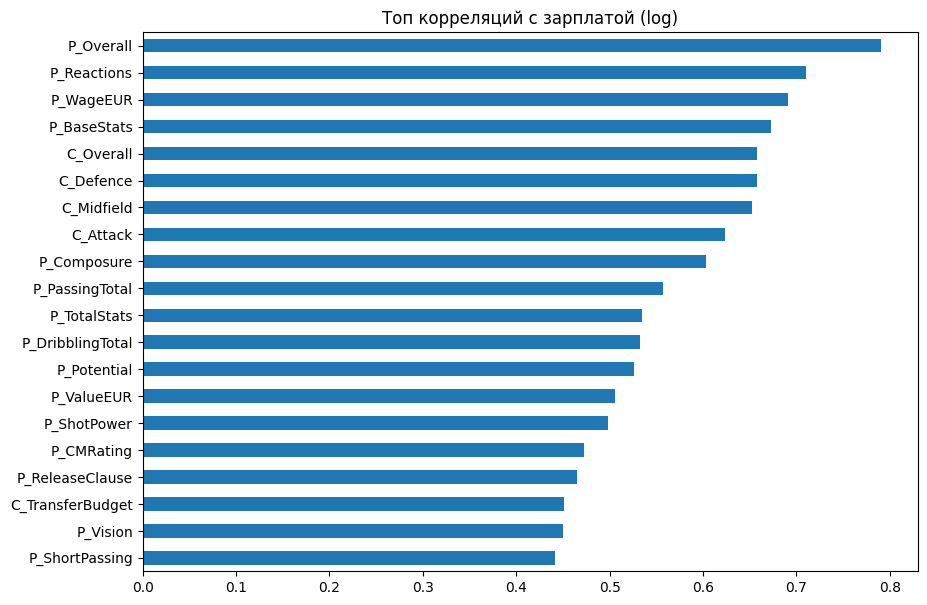

In [33]:
numeric_df = df_clean.select_dtypes(include=[np.number]).copy()
numeric_df['LogTarget'] = np.log1p(df_clean[TARGET])
corr = numeric_df.corr()['LogTarget'].drop('LogTarget')
top_corr = corr.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
corr[top_corr.index].sort_values().plot(kind='barh')
plt.title('Топ корреляций с зарплатой (log)')
plt.show()

## 8. Зависимости ключевых признаков

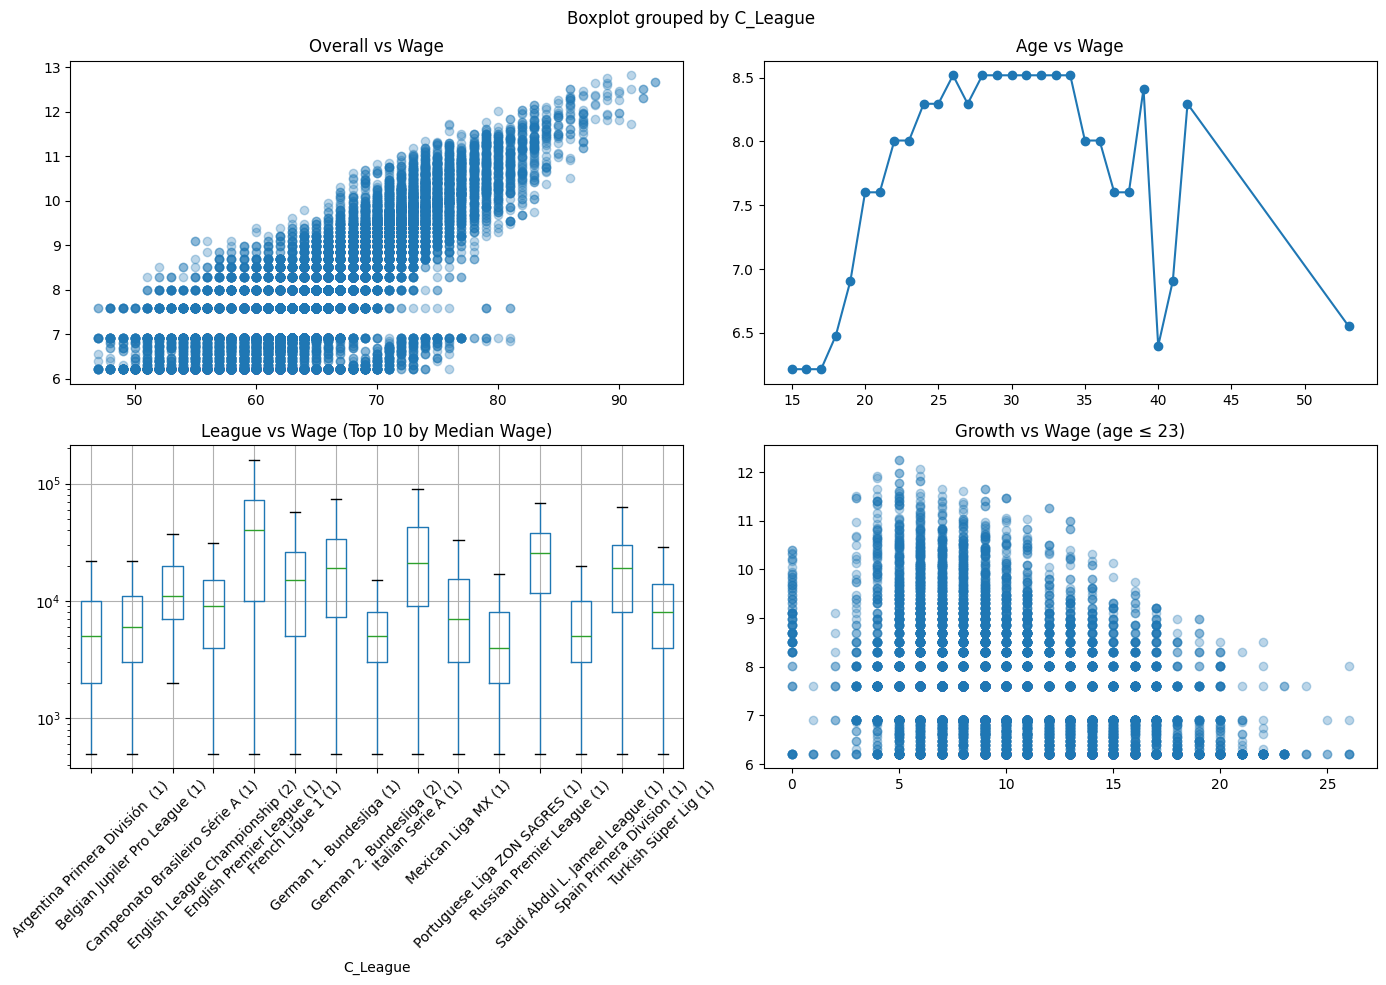

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(df_clean['P_Overall'], np.log1p(df_clean[TARGET]), alpha=0.3)
axes[0,0].set_title('Overall vs Wage')

age_val = df_clean.groupby('P_Age')[TARGET].median()
axes[0,1].plot(age_val.index, np.log1p(age_val.values), 'o-')
axes[0,1].set_title('Age vs Wage')

if 'C_League' in df_clean.columns:
    top_10_leagues = df_clean.groupby('C_League')[TARGET].median().nlargest(15).index
    df_top10 = df_clean[df_clean['C_League'].isin(top_10_leagues)]
    df_top10.boxplot(column=TARGET, by='C_League', ax=axes[1,0], showfliers=False)
    axes[1,0].set_yscale('log')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].set_title('League vs Wage (Top 10 by Median Wage)')

df_clean['_growth'] = df_clean['P_Potential'] - df_clean['P_Overall']
young = df_clean[df_clean['P_Age'] <= 23]
axes[1,1].scatter(young['_growth'], np.log1p(young[TARGET]), alpha=0.3)
axes[1,1].set_title('Growth vs Wage (age ≤ 23)')
df_clean = df_clean.drop(columns=['_growth'])

plt.tight_layout()
plt.show()

## 9. Статистика категориальных

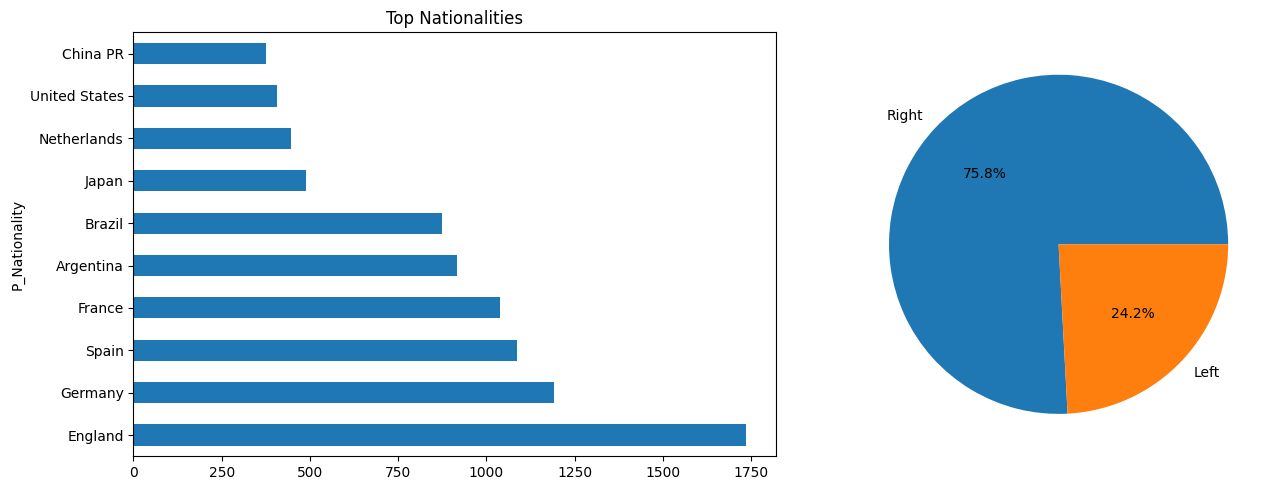

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'P_Nationality' in df_clean.columns:
    df_clean['P_Nationality'].value_counts().head(10).plot(kind='barh', ax=axes[0])
    axes[0].set_title('Top Nationalities')
if 'P_PreferredFoot' in df_clean.columns:
    df_clean['P_PreferredFoot'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
plt.tight_layout()
plt.show()

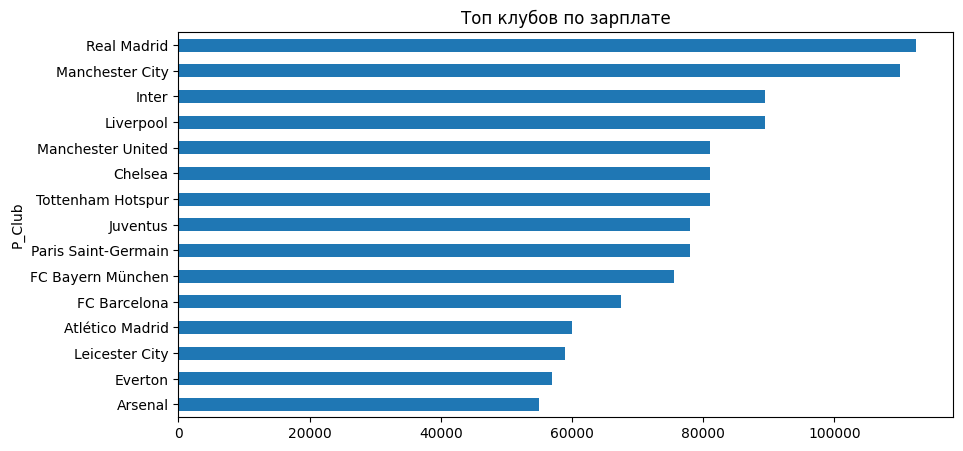

In [36]:
if 'P_Club' in df_clean.columns:
    top_clubs = df_clean.groupby('P_Club')[TARGET].median().sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 5))
    top_clubs.sort_values().plot(kind='barh')
    plt.title('Топ клубов по зарплате')
    plt.show()

## 10. RAW SPLIT

In [37]:
train_raw, val_raw, test_raw = raw_split(df_clean)

Сплит: train=13142, val=2816, test=2817


## 11. LeagueRank только по train

In [38]:
league_rank = build_league_rank(train_raw)

# Сохраняем сразу — C_League будет удалена после encode_data
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump(league_rank, '../models/league_rank_dict.joblib')
print('league_rank_dict сохранён')

league_rank_dict сохранён


## 12. Feature Engineering

In [ ]:
train = feature_engineering(train_raw, league_rank)
val   = feature_engineering(val_raw,   league_rank)
test  = feature_engineering(test_raw,  league_rank)

print("Train columns:", train.columns.tolist())
print("New columns:", [c for c in train.columns if c not in train_raw.columns])

Train columns: 109 ['P_ID', 'P_Name', 'P_FullName', 'P_Age', 'P_Height', 'P_Weight', 'P_PhotoUrl', 'P_Nationality', 'P_Overall', 'P_Potential', 'P_Growth', 'P_TotalStats', 'P_BaseStats', 'P_Positions', 'P_BestPosition', 'P_Club', 'P_ValueEUR', 'P_WageEUR', 'P_ReleaseClause', 'P_ClubPosition', 'P_ContractUntil', 'P_ClubNumber', 'P_ClubJoined', 'P_OnLoad', 'P_NationalTeam', 'P_NationalPosition', 'P_NationalNumber', 'P_PreferredFoot', 'P_IntReputation', 'P_WeakFoot', 'P_SkillMoves', 'P_AttackingWorkRate', 'P_DefensiveWorkRate', 'P_PaceTotal', 'P_ShootingTotal', 'P_PassingTotal', 'P_DribblingTotal', 'P_DefendingTotal', 'P_PhysicalityTotal', 'P_Crossing', 'P_Finishing', 'P_HeadingAccuracy', 'P_ShortPassing', 'P_Volleys', 'P_Dribbling', 'P_Curve', 'P_FKAccuracy', 'P_LongPassing', 'P_BallControl', 'P_Acceleration', 'P_SprintSpeed', 'P_Agility', 'P_Reactions', 'P_Balance', 'P_ShotPower', 'P_Jumping', 'P_Stamina', 'P_Strength', 'P_LongShots', 'P_Aggression', 'P_Interceptions', 'P_Positioning', 

## 13. Удаление выбросов

In [40]:
train = remove_outliers(train)
val   = remove_outliers(val)
test  = remove_outliers(test)

После удаления выбросов: 12,999 строк
После удаления выбросов: 2,787 строк
После удаления выбросов: 2,786 строк


## 14. Отбор фич


In [47]:
train = encode_data(train)
val   = encode_data(val)
test  = encode_data(test)
print("Final Train columns:", len(train.columns.tolist()), train.columns.tolist())

Final Train columns: 23 ['P_Age', 'P_Overall', 'P_Potential', 'P_IntReputation', 'P_WeakFoot', 'P_SkillMoves', 'P_PaceTotal', 'P_ShootingTotal', 'P_PassingTotal', 'P_DribblingTotal', 'P_DefendingTotal', 'P_PhysicalityTotal', 'C_Overall', 'C_TransferBudget', 'C_DomesticPrestige', 'C_IntPrestige', 'Growth', 'OverallSquared', 'ContractYearsLeft', 'Club_Strength', 'LeagueRank', 'IsTopLeague', 'P_WageEUR']


In [42]:
print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)

Train: (12999, 23)
Val: (2787, 23)
Test: (2786, 23)
